In [1]:
import sys

print(sys.executable)

C:\Users\NuKe\OneDrive\Desktop\SKINORA\backend\venv\Scripts\python.exe


In [2]:
import torch
import cv2
import pandas
import numpy
import PIL

print("PyTorch:", torch.__version__)
print("OpenCV:", cv2.__version__)
print("Everything is working!")

PyTorch: 2.14.0+cpu
OpenCV: 5.0.0
Everything is working!


In [3]:
from pathlib import Path

dataset_path = Path("../datasets/raw/ACNE04")

print("Dataset exists:", dataset_path.exists())
print("Dataset path:", dataset_path.resolve())

Dataset exists: True
Dataset path: C:\Users\NuKe\OneDrive\Desktop\SKINORA\ml\datasets\raw\ACNE04


In [4]:
for item in dataset_path.iterdir():
    print(item.name, "->", "DIR" if item.is_dir() else "FILE")

acne_1024 -> DIR
sim_acne.csv -> FILE


In [5]:
import pandas as pd

In [6]:
csv_path = dataset_path / "sim_acne.csv"

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (1400, 7)

Columns:
['Unnamed: 0', 'patient_id', 'date', 'block', 'day', 'treatment', 'AcneSeverity']


In [7]:
df.head()

,Unnamed: 0,patient_id,date,block,day,treatment,AcneSeverity
0,0,1,2018-01-01,1,1,Baseline,3.000
1,1,1,2018-01-02,1,2,Baseline,2.930
2,2,1,2018-01-03,1,3,Baseline,3.000
3,3,1,2018-01-04,1,4,Baseline,2.971
4,4,1,2018-01-05,1,5,Baseline,3.000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    1400 non-null   int64  
 1   patient_id    1400 non-null   int64  
 2   date          1400 non-null   str    
 3   block         1400 non-null   int64  
 4   day           1400 non-null   int64  
 5   treatment     1400 non-null   str    
 6   AcneSeverity  1400 non-null   float64
dtypes: float64(1), int64(4), str(2)
memory usage: 76.7 KB


In [9]:
for column in df.columns:
    print("\n==============================")
    print(column)
    print("==============================")
    print(df[column].value_counts(dropna=False).head(20))


Unnamed: 0
Unnamed: 0
0     10
1     10
2     10
3     10
4     10
5     10
6     10
7     10
8     10
9     10
10    10
11    10
12    10
13    10
14    10
15    10
16    10
17    10
18    10
19    10
Name: count, dtype: int64

patient_id
patient_id
1     140
2     140
3     140
4     140
5     140
6     140
7     140
8     140
9     140
10    140
Name: count, dtype: int64

date
date
2018-01-01    10
2018-01-02    10
2018-01-03    10
2018-01-04    10
2018-01-05    10
2018-01-06    10
2018-01-07    10
2018-01-08    10
2018-01-09    10
2018-01-10    10
2018-01-11    10
2018-01-12    10
2018-01-13    10
2018-01-14    10
2018-01-15    10
2018-01-16    10
2018-01-17    10
2018-01-18    10
2018-01-19    10
2018-01-20    10
Name: count, dtype: int64

block
block
1    280
2    280
3    280
4    280
5    280
Name: count, dtype: int64

day
day
1     10
2     10
3     10
4     10
5     10
6     10
7     10
8     10
9     10
10    10
11    10
12    10
13    10
14    10
15    10
16    10
17    10

In [10]:
image_dir = dataset_path / "acne_1024"

images = list(image_dir.rglob("*"))

print("Total files:", len(images))

for image in images[:20]:
    print(image.name)

Total files: 3211
acne0_1024
acne1_1024
acne2_1024
acne3_1024
acne3_512_selection
all_1024
small_1024
small_1024_renamed
levle0_1.jpg
levle0_10.jpg
levle0_100.jpg
levle0_101.jpg
levle0_102.jpg
levle0_103.jpg
levle0_104.jpg
levle0_105.jpg
levle0_106.jpg
levle0_107.jpg
levle0_108.jpg
levle0_109.jpg


In [11]:
from collections import Counter

extensions = Counter(
    file.suffix.lower()
    for file in images
    if file.is_file()
)

extensions

Counter({'.jpg': 3199, '.jsonl': 2, '.py': 2})

In [12]:
image_files = [
    file for file in images
    if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

print("Images found:", len(image_files))

first_image = image_files[0]

print("First image:", first_image)

Images found: 3199
First image: ..\datasets\raw\ACNE04\acne_1024\acne0_1024\levle0_1.jpg


In [13]:
from PIL import Image
img = Image.open(first_image)

print("Size:", img.size)
print("Mode:", img.mode)

Size: (1024, 1024)
Mode: RGB


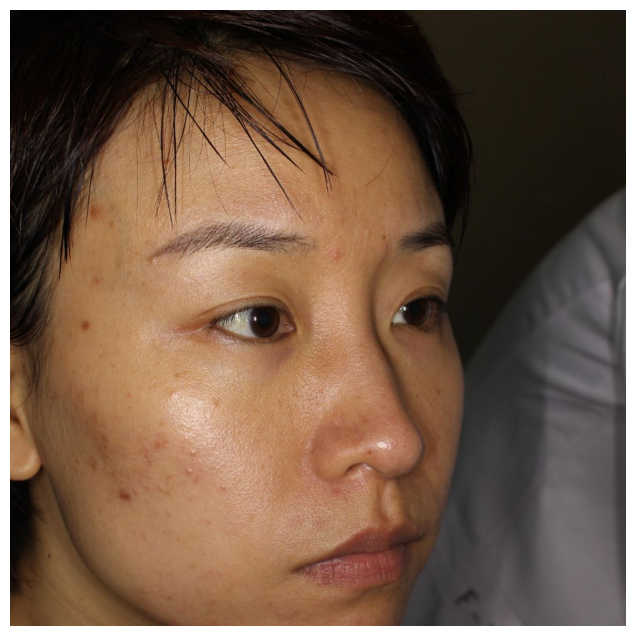

In [14]:
import matplotlib.pyplot as plt

img = Image.open(first_image)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [15]:
for file in images:
    if file.suffix.lower() in [".jsonl", ".py"]:
        print(file)

..\datasets\raw\ACNE04\acne_1024\acne3_1024\metadata_acne3.jsonl
..\datasets\raw\ACNE04\acne_1024\all_1024\metadata.jsonl
..\datasets\raw\ACNE04\acne_1024\small_1024\main.py
..\datasets\raw\ACNE04\acne_1024\small_1024_renamed\main.py


In [16]:
jsonl_files = [
    file for file in images
    if file.suffix.lower() == ".jsonl"
]

for file in jsonl_files:
    print("\nFILE:", file)
    with open(file, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            print(line[:500])
            if i >= 2:
                break


FILE: ..\datasets\raw\ACNE04\acne_1024\acne3_1024\metadata_acne3.jsonl
{"file_name": "levle3_87.jpg", "prompt": "photo of a person with acne3, a woman with ac ac ac ac ac ac ac ac ac ac ac ac ac ac ac ac ac ac"}

{"file_name": "levle3_85.jpg", "prompt": "photo of a person with acne3, a woman with acne on her face"}

{"file_name": "levle3_142.jpg", "prompt": "photo of a person with acne3, a man with a lot of bruises on his face"}


FILE: ..\datasets\raw\ACNE04\acne_1024\all_1024\metadata.jsonl
{"file_name": "levle2_134.jpg", "prompt": "photo of a person with acne2"}

{"file_name": "levle0_144.jpg", "prompt": "photo of a person with acne0"}

{"file_name": "levle1_564.jpg", "prompt": "photo of a person with acne1"}



In [17]:
import json
from collections import Counter
from pathlib import Path

jsonl_files = [
    file for file in images
    if file.suffix.lower() == ".jsonl"
]

for jsonl_file in jsonl_files:
    records = []

    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line:
                records.append(json.loads(line))

    print("=" * 60)
    print("FILE:", jsonl_file.name)
    print("Number of records:", len(records))

    print("\nFirst record:")
    print(records[0])

    print("\nKeys:")
    print(records[0].keys())

FILE: metadata_acne3.jsonl
Number of records: 115

First record:
{'file_name': 'levle3_87.jpg', 'prompt': 'photo of a person with acne3, a woman with ac ac ac ac ac ac ac ac ac ac ac ac ac ac ac ac ac ac'}

Keys:
dict_keys(['file_name', 'prompt'])
FILE: metadata.jsonl
Number of records: 1406

First record:
{'file_name': 'levle2_134.jpg', 'prompt': 'photo of a person with acne2'}

Keys:
dict_keys(['file_name', 'prompt'])


In [18]:
for jsonl_file in jsonl_files:

    levels = Counter()

    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            record = json.loads(line)

            filename = record.get("file_name", "")

            if filename.startswith("level"):
                level = filename.split("_")[0]
                levels[level] += 1

    print(jsonl_file.name)
    print(levels)

metadata_acne3.jsonl
Counter()
metadata.jsonl
Counter()


In [19]:
import json
import re
from collections import Counter

for jsonl_file in jsonl_files:
    levels = Counter()

    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue

            record = json.loads(line)
            prompt = record["prompt"].lower()

            match = re.search(r"acne(\d+)", prompt)

            if match:
                levels[f"acne{match.group(1)}"] += 1

    print(jsonl_file.name)
    print(levels)

metadata_acne3.jsonl
Counter({'acne3': 115})
metadata.jsonl
Counter({'acne1': 623, 'acne0': 491, 'acne2': 177, 'acne3': 115})


In [20]:
total_records = 0

for jsonl_file in jsonl_files:
    count = 0

    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                count += 1

    print(jsonl_file.name, count)
    total_records += count

print("Total metadata records:", total_records)

metadata_acne3.jsonl 115
metadata.jsonl 1406
Total metadata records: 1521


In [21]:
import json
import re
from collections import Counter

all_labels = Counter()

for jsonl_file in jsonl_files:
    labels = Counter()

    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue

            record = json.loads(line)
            prompt = record.get("prompt", "").lower()

            matches = re.findall(r"acne(\d+)", prompt)

            if matches:
                labels[matches[0]] += 1
                all_labels[matches[0]] += 1

    print(jsonl_file.name)
    print(labels)

print("\nALL METADATA")
print(all_labels)
print("Total labeled records:", sum(all_labels.values()))

metadata_acne3.jsonl
Counter({'3': 115})
metadata.jsonl
Counter({'1': 623, '0': 491, '2': 177, '3': 115})

ALL METADATA
Counter({'1': 623, '0': 491, '3': 230, '2': 177})
Total labeled records: 1521


In [22]:
missing_labels = []

for jsonl_file in jsonl_files:
    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue

            record = json.loads(line)
            prompt = record.get("prompt", "").lower()

            if not re.search(r"acne\d+", prompt):
                missing_labels.append(record)

print("Records without acne level:", len(missing_labels))

for record in missing_labels[:10]:
    print(record)

Records without acne level: 0


In [23]:
for folder in dataset_path.rglob("*"):
    if folder.is_dir():
        files = [p for p in folder.iterdir() if p.is_file()]
        print(folder.relative_to(dataset_path), ":", len(files), "files")

acne_1024 : 0 files
acne_1024\acne0_1024 : 483 files
acne_1024\acne1_1024 : 623 files
acne_1024\acne2_1024 : 175 files
acne_1024\acne3_1024 : 97 files
acne_1024\acne3_512_selection : 16 files
acne_1024\all_1024 : 1407 files
acne_1024\small_1024 : 201 files
acne_1024\small_1024_renamed : 201 files


In [24]:
for folder in dataset_path.rglob("*"):
    if folder.is_dir():
        image_count = sum(
            1 for p in folder.rglob("*")
            if p.is_file() and p.suffix.lower() in [".jpg", ".jpeg", ".png"]
        )

        if image_count > 0:
            print(folder.relative_to(dataset_path), ":", image_count, "images")

acne_1024 : 3199 images
acne_1024\acne0_1024 : 483 images
acne_1024\acne1_1024 : 623 images
acne_1024\acne2_1024 : 175 images
acne_1024\acne3_1024 : 96 images
acne_1024\acne3_512_selection : 16 images
acne_1024\all_1024 : 1406 images
acne_1024\small_1024 : 200 images
acne_1024\small_1024_renamed : 200 images


In [25]:
metadata_records = []

for jsonl_file in jsonl_files:
    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue

            record = json.loads(line)
            metadata_records.append({
                "file_name": record["file_name"],
                "prompt": record["prompt"]
            })

print("Metadata records:", len(metadata_records))

Metadata records: 1521


In [26]:
# Create lookup of all image filenames
image_lookup = {}

for image_path in image_files:
    image_lookup.setdefault(image_path.name, []).append(image_path)

print("Unique image filenames:", len(image_lookup))

Unique image filenames: 1622


In [27]:
missing_images = []

for record in metadata_records:
    filename = record["file_name"]

    if filename not in image_lookup:
        missing_images.append(filename)

print("Missing images:", len(missing_images))

if missing_images:
    print(missing_images[:20])

Missing images: 0


In [28]:
duplicate_files = {
    filename: paths
    for filename, paths in image_lookup.items()
    if len(paths) > 1
}

print("Duplicate filenames:", len(duplicate_files))

for filename, paths in list(duplicate_files.items())[:20]:
    print("\n", filename)
    for path in paths:
        print("   ", path)

Duplicate filenames: 1377

 levle0_1.jpg
    ..\datasets\raw\ACNE04\acne_1024\acne0_1024\levle0_1.jpg
    ..\datasets\raw\ACNE04\acne_1024\all_1024\levle0_1.jpg
    ..\datasets\raw\ACNE04\acne_1024\small_1024\levle0_1.jpg

 levle0_10.jpg
    ..\datasets\raw\ACNE04\acne_1024\acne0_1024\levle0_10.jpg
    ..\datasets\raw\ACNE04\acne_1024\all_1024\levle0_10.jpg
    ..\datasets\raw\ACNE04\acne_1024\small_1024\levle0_10.jpg

 levle0_100.jpg
    ..\datasets\raw\ACNE04\acne_1024\acne0_1024\levle0_100.jpg
    ..\datasets\raw\ACNE04\acne_1024\all_1024\levle0_100.jpg

 levle0_101.jpg
    ..\datasets\raw\ACNE04\acne_1024\acne0_1024\levle0_101.jpg
    ..\datasets\raw\ACNE04\acne_1024\all_1024\levle0_101.jpg

 levle0_102.jpg
    ..\datasets\raw\ACNE04\acne_1024\acne0_1024\levle0_102.jpg
    ..\datasets\raw\ACNE04\acne_1024\all_1024\levle0_102.jpg

 levle0_103.jpg
    ..\datasets\raw\ACNE04\acne_1024\acne0_1024\levle0_103.jpg
    ..\datasets\raw\ACNE04\acne_1024\all_1024\levle0_103.jpg

 levle0_104.j

In [30]:
import json
import re
import pandas as pd
from pathlib import Path

# Dataset location
dataset_path = Path("../datasets/raw/ACNE04")

# Find the two JSONL metadata files
jsonl_files = list(dataset_path.rglob("*.jsonl"))

print("Found JSONL files:")
for f in jsonl_files:
    print(f)

# Build the dataframe
records = []

for jsonl_file in jsonl_files:
    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue

            record = json.loads(line)

            filename = record["file_name"]
            prompt = record["prompt"]

            # Extract acne level from prompt: acne0, acne1, acne2, acne3
            match = re.search(r"acne(\d+)", prompt.lower())

            if match:
                records.append({
                    "filename": filename,
                    "acne_level": int(match.group(1)),
                    "prompt": prompt,
                    "source_metadata": jsonl_file.name
                })

# Create dataframe
df_acne = pd.DataFrame(records)

print("\nTotal records:", len(df_acne))
print("\nClass distribution:")
print(df_acne["acne_level"].value_counts().sort_index())

print("\nFirst 10 records:")
display(df_acne.head(10))

Found JSONL files:
..\datasets\raw\ACNE04\acne_1024\acne3_1024\metadata_acne3.jsonl
..\datasets\raw\ACNE04\acne_1024\all_1024\metadata.jsonl

Total records: 1521

Class distribution:
acne_level
0    491
1    623
2    177
3    230
Name: count, dtype: int64

First 10 records:


,filename,acne_level,prompt,source_metadata
0,levle3_87.jpg,3,"photo of a person with acne3, a woman with ac ...",metadata_acne3.jsonl
1,levle3_85.jpg,3,"photo of a person with acne3, a woman with acn...",metadata_acne3.jsonl
2,levle3_142.jpg,3,"photo of a person with acne3, a man with a lot...",metadata_acne3.jsonl
3,levle3_83.jpg,3,"photo of a person with acne3, a woman with red...",metadata_acne3.jsonl
4,levle3_31.jpg,3,"photo of a person with acne3, a woman with acu...",metadata_acne3.jsonl
5,levle3_67.jpg,3,"photo of a person with acne3, a woman with acu...",metadata_acne3.jsonl
6,levle3_0.jpg,3,"photo of a person with acne3, a man with acus ...",metadata_acne3.jsonl
7,levle3_5.jpg,3,"photo of a person with acne3, a man with acis ...",metadata_acne3.jsonl
8,levle3_131.jpg,3,"photo of a person with acne3, a man with acus ...",metadata_acne3.jsonl
9,levle3_2.jpg,3,"photo of a person with acne3, a man with a lar...",metadata_acne3.jsonl


In [31]:
print(df_acne.shape)
print(df_acne.dtypes)

(1521, 4)
filename             str
acne_level         int64
prompt               str
source_metadata      str
dtype: object


In [32]:
print("Duplicate metadata filenames:",
      df_acne["filename"].duplicated().sum())

Duplicate metadata filenames: 115


In [33]:
from collections import defaultdict

image_files = [
    file
    for file in dataset_path.rglob("*")
    if file.is_file()
    and file.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

image_lookup = defaultdict(list)

for image_path in image_files:
    image_lookup[image_path.name].append(image_path)

print("Physical image files:", len(image_files))
print("Unique filenames:", len(image_lookup))

Physical image files: 3199
Unique filenames: 1622


In [34]:
print(
    "Duplicate metadata filenames:",
    df_acne["filename"].duplicated().sum()
)

Duplicate metadata filenames: 115


In [35]:
print(
    df_acne[df_acne["filename"].duplicated(keep=False)]
    .sort_values("filename")
    .head(20)
)

            filename  acne_level  \
182     levle3_0.jpg           3   
6       levle3_0.jpg           3   
1022    levle3_1.jpg           3   
77      levle3_1.jpg           3   
618   levle3_100.jpg           3   
44    levle3_100.jpg           3   
756   levle3_101.jpg           3   
53    levle3_101.jpg           3   
213   levle3_102.jpg           3   
10    levle3_102.jpg           3   
114   levle3_103.jpg           3   
1515  levle3_103.jpg           3   
989   levle3_105.jpg           3   
74    levle3_105.jpg           3   
91    levle3_106.jpg           3   
1202  levle3_106.jpg           3   
93    levle3_107.jpg           3   
1225  levle3_107.jpg           3   
37    levle3_108.jpg           3   
521   levle3_108.jpg           3   

                                                 prompt       source_metadata  
182                        photo of a person with acne3        metadata.jsonl  
6     photo of a person with acne3, a man with acus ...  metadata_acne3.jsonl  
102

In [36]:
df_acne["image_paths"] = df_acne["filename"].apply(
    lambda x: image_lookup.get(x, [])
)

df_acne["num_copies"] = df_acne["image_paths"].apply(len)

print(df_acne["num_copies"].value_counts().sort_index())

num_copies
1      48
2    1223
3     250
Name: count, dtype: int64


In [37]:
missing = df_acne[df_acne["num_copies"] == 0]

print("Missing labeled images:", len(missing))

if len(missing) > 0:
    display(missing)

Missing labeled images: 0


In [38]:
for _, row in df_acne.head(10).iterrows():
    print("\n", row["filename"])
    
    for path in row["image_paths"]:
        print("   ", path)


 levle3_87.jpg
    ..\datasets\raw\ACNE04\acne_1024\acne3_1024\levle3_87.jpg
    ..\datasets\raw\ACNE04\acne_1024\all_1024\levle3_87.jpg

 levle3_85.jpg
    ..\datasets\raw\ACNE04\acne_1024\acne3_1024\levle3_85.jpg
    ..\datasets\raw\ACNE04\acne_1024\all_1024\levle3_85.jpg
    ..\datasets\raw\ACNE04\acne_1024\small_1024\levle3_85.jpg

 levle3_142.jpg
    ..\datasets\raw\ACNE04\acne_1024\acne3_1024\levle3_142.jpg
    ..\datasets\raw\ACNE04\acne_1024\all_1024\levle3_142.jpg

 levle3_83.jpg
    ..\datasets\raw\ACNE04\acne_1024\acne3_1024\levle3_83.jpg
    ..\datasets\raw\ACNE04\acne_1024\all_1024\levle3_83.jpg
    ..\datasets\raw\ACNE04\acne_1024\small_1024\levle3_83.jpg

 levle3_31.jpg
    ..\datasets\raw\ACNE04\acne_1024\acne3_1024\levle3_31.jpg
    ..\datasets\raw\ACNE04\acne_1024\all_1024\levle3_31.jpg
    ..\datasets\raw\ACNE04\acne_1024\small_1024\levle3_31.jpg

 levle3_67.jpg
    ..\datasets\raw\ACNE04\acne_1024\all_1024\levle3_67.jpg

 levle3_0.jpg
    ..\datasets\raw\ACNE04\acn

In [39]:
all_1024_dir = dataset_path / "acne_1024" / "all_1024"

all_1024_images = {
    p.name
    for p in all_1024_dir.iterdir()
    if p.is_file() and p.suffix.lower() in [".jpg", ".jpeg", ".png"]
}

print("all_1024 images:", len(all_1024_images))

metadata_main = set()

main_jsonl = all_1024_dir / "metadata.jsonl"

with open(main_jsonl, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            record = json.loads(line)
            metadata_main.add(record["file_name"])

print("metadata.jsonl records:", len(metadata_main))

print(
    "Metadata records without image:",
    len(metadata_main - all_1024_images)
)

print(
    "Images without metadata:",
    len(all_1024_images - metadata_main)
)

all_1024 images: 1406
metadata.jsonl records: 1406
Metadata records without image: 0
Images without metadata: 0


In [40]:
acne3_dir = dataset_path / "acne_1024" / "acne3_1024"

acne3_images = {
    p.name
    for p in acne3_dir.iterdir()
    if p.is_file() and p.suffix.lower() in [".jpg", ".jpeg", ".png"]
}

acne3_metadata = set()

acne3_jsonl = acne3_dir / "metadata_acne3.jsonl"

with open(acne3_jsonl, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            record = json.loads(line)
            acne3_metadata.add(record["file_name"])

print("acne3 images:", len(acne3_images))
print("acne3 metadata:", len(acne3_metadata))

print(
    "Metadata without image:",
    len(acne3_metadata - acne3_images)
)

print(
    "Images without metadata:",
    len(acne3_images - acne3_metadata)
)

acne3 images: 96
acne3 metadata: 115
Metadata without image: 19
Images without metadata: 0


In [41]:
import json
import re
import pandas as pd
from pathlib import Path

# Canonical dataset
all_1024_dir = dataset_path / "acne_1024" / "all_1024"
metadata_file = all_1024_dir / "metadata.jsonl"

records = []

with open(metadata_file, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        record = json.loads(line)

        filename = record["file_name"]
        prompt = record["prompt"]

        match = re.search(r"acne(\d+)", prompt.lower())

        if match:
            acne_level = int(match.group(1))

            records.append({
                "filename": filename,
                "acne_level": acne_level,
                "prompt": prompt
            })

clean_df = pd.DataFrame(records)

print("Dataset size:", len(clean_df))
print("\nClass distribution:")
print(clean_df["acne_level"].value_counts().sort_index())

Dataset size: 1406

Class distribution:
acne_level
0    491
1    623
2    177
3    115
Name: count, dtype: int64


In [42]:
clean_df["image_path"] = clean_df["filename"].apply(
    lambda x: str(all_1024_dir / x)
)

print(clean_df.head())

         filename  acne_level                        prompt  \
0  levle2_134.jpg           2  photo of a person with acne2   
1  levle0_144.jpg           0  photo of a person with acne0   
2  levle1_564.jpg           1  photo of a person with acne1   
3  levle0_164.jpg           0  photo of a person with acne0   
4   levle2_32.jpg           2  photo of a person with acne2   

                                          image_path  
0  ..\datasets\raw\ACNE04\acne_1024\all_1024\levl...  
1  ..\datasets\raw\ACNE04\acne_1024\all_1024\levl...  
2  ..\datasets\raw\ACNE04\acne_1024\all_1024\levl...  
3  ..\datasets\raw\ACNE04\acne_1024\all_1024\levl...  
4  ..\datasets\raw\ACNE04\acne_1024\all_1024\levl...  


In [43]:
clean_df["exists"] = clean_df["image_path"].apply(
    lambda x: Path(x).exists()
)

print("Missing images:", (~clean_df["exists"]).sum())

Missing images: 0


In [44]:
clean_df = clean_df.drop(columns=["exists"])

In [45]:
print(
    "Duplicate filenames:",
    clean_df["filename"].duplicated().sum()
)

Duplicate filenames: 0


Saved to:
..\datasets\raw\processed\acne_dataset.csv


In [47]:
processed_dir = dataset_path.parent.parent / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

clean_df.to_csv(
    processed_dir / "acne_dataset.csv",
    index=False
)

print("Saved to:")
print(processed_dir.resolve())

Saved to:
C:\Users\NuKe\OneDrive\Desktop\SKINORA\ml\datasets\processed


In [48]:
print((processed_dir / "acne_dataset.csv").exists())

True


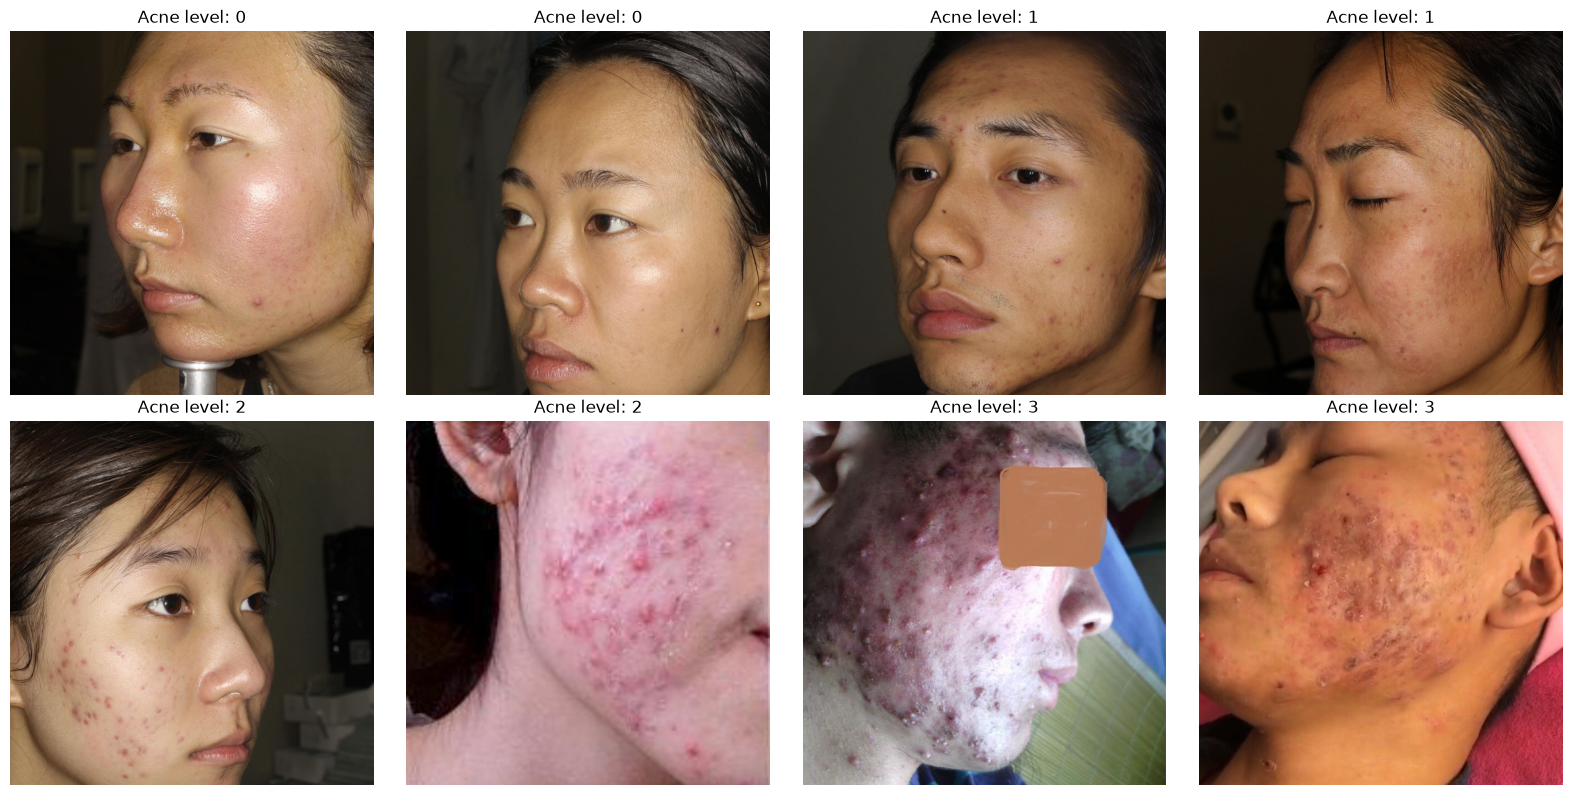

In [49]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (_, row) in zip(axes.ravel(), clean_df.groupby("acne_level").sample(n=2, random_state=42).iterrows()):
    img = Image.open(row["image_path"])

    ax.imshow(img)
    ax.set_title(f"Acne level: {row['acne_level']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

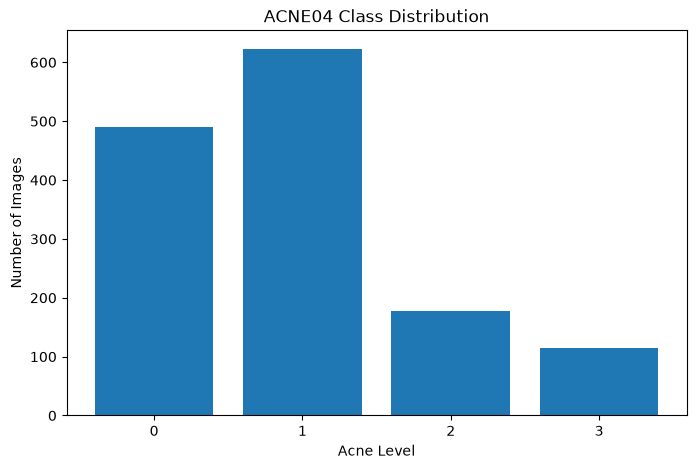

In [50]:
import matplotlib.pyplot as plt

class_counts = clean_df["acne_level"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.xlabel("Acne Level")
plt.ylabel("Number of Images")
plt.title("ACNE04 Class Distribution")
plt.show()

In [51]:
from sklearn.model_selection import train_test_split

# First: 70% train, 30% temporary
train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.30,
    stratify=clean_df["acne_level"],
    random_state=42
)

# Second: split the 30% into 15% validation and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["acne_level"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 984
Validation: 211
Test: 211


In [52]:
print("TRAIN")
print(train_df["acne_level"].value_counts().sort_index())

print("\nVALIDATION")
print(val_df["acne_level"].value_counts().sort_index())

print("\nTEST")
print(test_df["acne_level"].value_counts().sort_index())

TRAIN
acne_level
0    344
1    436
2    124
3     80
Name: count, dtype: int64

VALIDATION
acne_level
0    73
1    94
2    26
3    18
Name: count, dtype: int64

TEST
acne_level
0    74
1    93
2    27
3    17
Name: count, dtype: int64


In [53]:
train_files = set(train_df["filename"])
val_files = set(val_df["filename"])
test_files = set(test_df["filename"])

print("Train ∩ Validation:", len(train_files & val_files))
print("Train ∩ Test:", len(train_files & test_files))
print("Validation ∩ Test:", len(val_files & test_files))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [54]:
train_df.to_csv(
    processed_dir / "train.csv",
    index=False
)

val_df.to_csv(
    processed_dir / "val.csv",
    index=False
)

test_df.to_csv(
    processed_dir / "test.csv",
    index=False
)

print("Saved:")
print(processed_dir / "train.csv")
print(processed_dir / "val.csv")
print(processed_dir / "test.csv")

Saved:
..\datasets\processed\train.csv
..\datasets\processed\val.csv
..\datasets\processed\test.csv


In [55]:
from sklearn.model_selection import train_test_split

# 70% training, 30% temporary
train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.30,
    stratify=clean_df["acne_level"],
    random_state=42
)

# Split the temporary 30% equally:
# 15% validation, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["acne_level"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 984
Validation: 211
Test: 211


In [56]:
print("TRAIN")
print(train_df["acne_level"].value_counts().sort_index())

print("\nVALIDATION")
print(val_df["acne_level"].value_counts().sort_index())

print("\nTEST")
print(test_df["acne_level"].value_counts().sort_index())

TRAIN
acne_level
0    344
1    436
2    124
3     80
Name: count, dtype: int64

VALIDATION
acne_level
0    73
1    94
2    26
3    18
Name: count, dtype: int64

TEST
acne_level
0    74
1    93
2    27
3    17
Name: count, dtype: int64


In [57]:
processed_dir = Path("../datasets/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(processed_dir / "train.csv", index=False)
val_df.to_csv(processed_dir / "val.csv", index=False)
test_df.to_csv(processed_dir / "test.csv", index=False)

print("Files created:")

for file in [
    processed_dir / "train.csv",
    processed_dir / "val.csv",
    processed_dir / "test.csv"
]:
    print(file.resolve(), "->", file.exists())

Files created:
C:\Users\NuKe\OneDrive\Desktop\SKINORA\ml\datasets\processed\train.csv -> True
C:\Users\NuKe\OneDrive\Desktop\SKINORA\ml\datasets\processed\val.csv -> True
C:\Users\NuKe\OneDrive\Desktop\SKINORA\ml\datasets\processed\test.csv -> True
